In [1]:
from pathlib import Path
import os
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from sentence_transformers import CrossEncoder
from langchain_classic.retrievers import EnsembleRetriever
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=os.getenv("OPENAI_API_KEY")
)

vectorstore = FAISS.load_local(
    "../ml_vector_db",
    embeddings,
    allow_dangerous_deserialization=True
)


### Reranking Using Cross-encoder

In [4]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def cross_encoder_rerank(query, docs, top_n=6):

    pairs = [(query, d.page_content) for d in docs]

    scores = reranker.predict(pairs)  
    ranked = sorted(
        zip(docs, scores), 
        key=lambda x: x[1],
        reverse=True
    )
    return [doc for doc, score in ranked[:top_n]]


In [5]:
docs = list(vectorstore.docstore._dict.values())

bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 10

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

ensemble_retriever = EnsembleRetriever(
    retrievers=[vector_retriever, bm25_retriever],
    weights=[0.3, 0.7]
)

def retrieve(query):
    combined = ensemble_retriever.invoke(query)
    reranked = cross_encoder_rerank(query, combined)
    return reranked

In [6]:
def docs_to_text(docs):
    return "\n\n".join(d.page_content for d in docs)

def RAG(query):

    top_docs=retrieve(query)
    context=docs_to_text(top_docs)

    prompt = f"""
    You are a helpful RAG assistant.
    Use ONLY the information provided in the context to answer the question.
    Write the answer directly, without mentioning or implying that the information came from a context.
    
    Provide a clear and complete answer.
    Do not hallucinate or use outside knowledge.

    Context: {context}
    Question: {query}

    Answer (grounded in context):

    """


    completion = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0.0,
        messages=[{"role": "user", "content": prompt}]
    )

    return completion.choices[0].message.content



In [7]:
RAG("where is this text mentioned in document (give heading): penalising the theory")


'The text mentioning "penalising the theory" is found under the heading "overfitting."'

In [29]:
RAG("the pdf discusses a setting where the system is not told the right answer but must still identify internal organization; how is this situation explained")

'This situation is explained by the concept of unsupervised learning algorithms, which find structures in data that has not been labelled, classified, or categorised. Instead of responding to feedback, these algorithms identify commonalities in the data and react based on the presence or absence of such commonalities in each new piece of data. This approach allows the system to organize and understand the data internally without being provided with explicit correct answers.'

# Evaluation

In [8]:
import re
import numpy as np
from sklearn.metrics import ndcg_score
from sentence_transformers import SentenceTransformer, util

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness,
    RougeScore
)

from datasets import Dataset


### Manual Retrieval Evaluation Function

In [9]:
model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_retrieval_metrics(query, retrieved_docs, ground_truth_text, k=6):

    def is_semantically_relevant(gt_text, doc_text, threshold=0.5):
        emb_gt = model.encode(gt_text, convert_to_tensor=True)
        emb_doc = model.encode(doc_text, convert_to_tensor=True)
        score = util.cos_sim(emb_gt, emb_doc).item()
        return score > threshold

    relevant = []
    for d in retrieved_docs:
        is_relevant = is_semantically_relevant(ground_truth_text, d.page_content)
        relevant.append(is_relevant)

    current_k = min(len(relevant), k)
    relevant_k = relevant[:current_k]

    hit_rate = 1 if any(relevant_k) else 0

    precision = sum(relevant_k) / current_k if current_k else 0


    rank = relevant_k.index(True) + 1
    mrr = 1.0 / rank if rank else 0
 
    if current_k > 0:
        y_true = np.array([1 if x else 0 for x in relevant_k])
        y_score = np.arange(current_k, 0, -1)
        ndcg = float(ndcg_score([y_true], [y_score], k=current_k))
    else:
        ndcg = 0.0

    return {
        "hit_rate@k": hit_rate,
        "precision@k": precision,
        "mrr": mrr,
        "ndcg@k": ndcg
    }

In [10]:
GROUND_TRUTH = {
    "what are belief functions in machine learning": """
    The theory of belief functions, also referred to as evidence theory or Dempster–Shafer theory, 
    is a general framework for reasoning with uncertainty, with understood connections to other frameworks 
    such as probability, possibility and imprecise probability theories. These theoretical frameworks can 
    be thought of as a kind of learner and have some analogous properties of how evidence is combined 
    (e.g., Dempster's rule of combination)
    """ ,
    
    "explain generalization in machine learning": """
    Generalization in this context is the ability of a learning machine to perform accurately on new, 
    unseen examples/tasks after having experienced a learning data set. The training examples come from 
    some generally unknown probability distribution and the learner has to build a general model about 
    this space that enables it to produce sufficiently accurate predictions in new cases.
    """,
    
    "what is the role of the bias–variance decomposition": """
    The bias–variance decomposition is one way to quantify generalisation error.
    """
    ,
    
    "describe dimensionality reduction and the manifold hypothesis": """
    Dimensionality reduction is a process of reducing the number of random variables under consideration 
    by obtaining a set of principal variables. One popular method is PCA. The manifold hypothesis proposes 
    that high-dimensional data sets lie along low-dimensional manifolds, motivating manifold learning 
    and manifold regularisation.
    """
    ,
    
    "what is sparse dictionary learning": """
    Sparse dictionary learning is a feature learning method where a training example is represented as 
    a linear combination of basis functions and assumed to be a sparse matrix. It is strongly NP-hard. 
    Sparse dictionary learning has been applied in several contexts, including classification and image 
    denoising.
    """
    ,
    "what are supervised, unsupervised, and reinforcement learning": """
    Supervised learning: The computer is presented with example inputs and their desired outputs,
    given by a "teacher", and the goal is to learn a general rule that maps inputs to outputs.
    Unsupervised learning: No labels are given to the learning algorithm, leaving it on its own to
    find structure in its input.
    Reinforcement learning: A computer program interacts with a dynamic environment in which it
    must perform a certain goal. As it navigates its problem space, the program is provided feedback
    that's analogous to rewards, which it tries to maximise.
    """
    ,
    "what is a bayesian network": """
    A Bayesian network, belief network, or directed acyclic graphical model is a probabilistic graphical
    model that represents a set of random variables and their conditional independence with a directed
    acyclic graph (DAG).
    """
    ,
    "what does the overfitting image illustrate": """
    The overfitting image shows a blue line fitting noise in the training data, demonstrating a 
    model that is overly complex and matches random fluctuations rather than the true pattern.
    """,
    "what is feature learning": """
    Feature learning algorithms often attempt to preserve the information in their input but also transform it 
    in a way that makes it useful, often as a pre-processing step before performing classification or predictions.
    """,
    
    "the pdf discusses a learning setting where the system is not told the right answer but must still identify internal organization; how is this situation explained": """
    Unsupervised learning: No labels are given to the learning algorithm, leaving it on its own to find structure in its input.
    """
    
}

In [11]:
questions = []
answers = []
contexts = []
ground_truth_list = []
retrieval_metrics = []

for q, gt in GROUND_TRUTH.items():
    rag_answer = RAG(q)
    retrieved = retrieve(q)

    questions.append(q)
    answers.append(rag_answer)
    contexts.append([d.page_content for d in retrieved])
    ground_truth_list.append(gt)

    metrics = compute_retrieval_metrics(q, retrieved, gt, k=6)
    retrieval_metrics.append(metrics)


In [12]:
dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts,
    "ground_truth": ground_truth_list
})

In [13]:
llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [14]:
import nest_asyncio
nest_asyncio.apply()

In [15]:
rouge_metric = RougeScore(rouge_type='rougeL', mode='recall')

result = evaluate(
    dataset=dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        answer_correctness,
        context_precision,
        context_recall,
        rouge_metric
    ],
    llm=llm,
    embeddings=embeddings
)


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x1082062c0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x1082062c0> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._

In [18]:
df_ragas = result.to_pandas()
df_retrieval = pd.DataFrame(retrieval_metrics)

df = pd.concat([df_ragas, df_retrieval], axis=1)
df


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,answer_correctness,context_precision,context_recall,rouge_score(mode=recall),hit_rate@k,precision@k,mrr,ndcg@k
0,what are belief functions in machine learning,"[The theory of belief functions, also referred...","Belief functions, also known as evidence theor...","\n The theory of belief functions, also ref...",0.916667,0.836597,0.366295,1.00,1.0,0.348485,1,0.166667,1.0,1.000000
1,explain generalization in machine learning,[A core objective of a learner is to generalis...,Generalization in machine learning refers to t...,\n Generalization in this context is the ab...,1.000000,0.865539,0.420600,1.00,1.0,0.593220,1,0.666667,1.0,0.943866
2,what is the role of the bias–variance decompos...,[A core objective of a learner is to generalis...,The bias–variance decomposition is a method us...,\n The bias–variance decomposition is one w...,0.500000,0.840116,0.314853,1.00,1.0,0.727273,1,0.166667,1.0,1.000000
3,describe dimensionality reduction and the mani...,[Dimensionality reduction is a process of redu...,Dimensionality reduction is the process of red...,\n Dimensionality reduction is a process of...,0.909091,0.741773,0.584832,0.75,1.0,0.913043,1,0.333333,1.0,1.000000
4,what is sparse dictionary learning,[hard and difficult to solve approximately. A...,Sparse dictionary learning is a feature learni...,\n Sparse dictionary learning is a feature ...,0.833333,0.925443,0.760655,1.00,1.0,0.702128,1,0.333333,1.0,1.000000


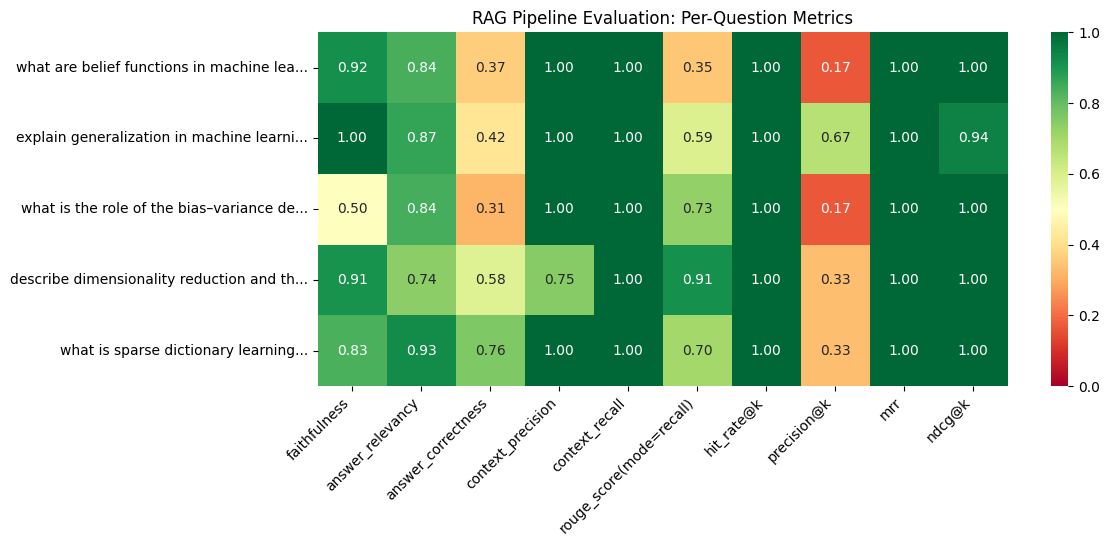

In [20]:
plt.figure(figsize=(12, 6))

numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(
    df[numeric_cols],
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    vmin=0,
    vmax=1,
    yticklabels=[q[:40] + "..." for q in questions]
)

plt.title("RAG Pipeline Evaluation: Per-Question Metrics")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()


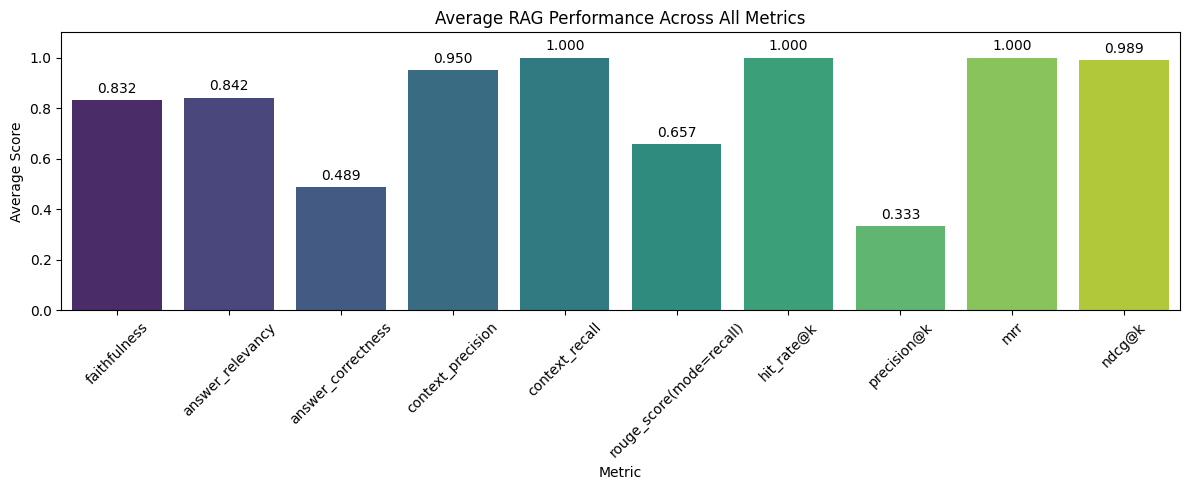

In [22]:
means = df[numeric_cols].mean().reset_index()
means.columns = ["Metric", "Average Score"]

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=means,
    x="Metric",
    y="Average Score",
    palette="viridis"
)

# Annotate each bar with score
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.ylim(0, 1.1)
plt.title("Average RAG Performance Across All Metrics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
